# Gal4M Tutorial 2 — The any-to-any multimodal transformer

Tutorial 1 turned every modality of a galaxy into a short sequence of **discrete
tokens**. Now we train a single **FourM**-style transformer over the
*concatenation* of those token streams. The payoff is **any-to-any prediction**:
at inference we feed whatever modalities we *have* and ask the model to generate
any modality we *want* — image → star-formation history, image → density profiles,
image → halo mass, and so on.

We train on the **multi-redshift** set (19,118 galaxies, z = 0.0 → 0.4) with all
**12 modalities** (galaxy image, SFH, gas/DM profile, and 8 scalars), and validate
on the held-out 500-galaxy set from Tutorial 1.

![Masked multimodal transformer](assets/Image-tokenized-multimodal-learning.png)

### The masked multimodal objective

FourM trains with a simple masking game (`sim.dataset.prepare_mod_dict`):

* Each step, the modalities of a galaxy are randomly split into an **encoder** set
  and a **decoder** set.
* The **encoder** sees *all* tokens of its modalities (full context).
* The **decoder** must *predict* all tokens of its modalities (they are masked out).
* Loss = mean per-modality cross-entropy (`loss_type="mod"`), so every modality
  counts equally regardless of how many tokens it has.

Because the split is random every step, one network learns **every** conditional
distribution `p(target modalities | context modalities)` at once. At inference we
simply *fix* the split: known modalities → encoder, wanted modalities → decoder.

```
   encoder (visible)                 decoder (predicted)
 ┌─────────────────────┐           ┌───────────────────────┐
 │ galaxy image tokens │  ──────►  │ SFH / profile / scalar │
 └─────────────────────┘           └───────────────────────┘
```

### Three training choices that matter

* **Galaxy image pinned to the encoder** (`encoder_only_mods`) — the 1024-token
  image is the natural input; making it a decoder target would swamp the
  per-modality loss.
* **Stochastic mask fraction** `MASK_FRAC = (0.15, 0.85)` — the decoder fraction is
  sampled uniformly each step, so the model practises the whole conditioning
  spectrum (from "encode one, predict one" to "encode most, predict one") instead
  of only 50/50 splits. This is the single biggest lever for the image-only
  downstream tasks below.
* **Soft cross-entropy** (`soft_ce_sigma = 1.0`) on the ordinal scalar modalities —
  the target is a 1-bin-wide Gaussian over the codebook instead of a hard one-hot,
  giving the model partial credit for off-by-one-bin guesses. This calibrates the
  scalar posterior (argmax ≈ expected value), so the **uncertainties** in Step 3
  are trustworthy.

### Reliable checkpoint selection

The encoder/decoder split is random, so scoring the held-out set on a *fresh*
random mask every epoch makes the validation loss bounce (a checkpoint can win
just by drawing a lucky, heavily-conditioned mask). We pin a fixed seed for the
validation pass (`val_seed`), so the validation loss is comparable across epochs
and the saved checkpoint tracks real generalization rather than mask noise.

## How this notebook is meant to be run

Tokenizing the full dataset (the image codec) and training the transformer need a
**GPU**, so this is the same two-pass workflow as Tutorial 1, switched by
`GAL4M_TRAIN`:

1. **Load (default):** run normally. Tokenization and training are skipped; the
   published token files, transformer, and codecs are loaded and the any-to-any
   predictions are rendered on the held-out 500-galaxy validation set. Runs on a
   laptop.
2. **Train (GPU):** set `GAL4M_TRAIN=1`. The cells below then tokenize the dataset
   with the Tutorial-1 codecs and train the transformer inline
   (`python -m sim.train_transformer`, ~11 h on one V100).

> **Data & checkpoints.** This notebook pulls its data and pre-trained
> checkpoints from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial) — each file downloads
> automatically on first use (into `data/` and `checkpoints/`). To fetch
> everything up front instead, run
> `from sim.hub import download_data, download_checkpoints; download_data(); download_checkpoints()`.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from sim.hub import (DATA_DIR, CHECKPOINTS_DIR,   # local-first; auto-downloads from the HF Hub
                     data_path, checkpoint_path)

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN  = os.environ.get("GAL4M_TRAIN", "0") == "1"

TRAIN_FILES = [os.path.join(DATA_DIR, f"Snap{s}.npz") for s in (72, 78, 84, 91, 99)]
VAL_FILE    = os.path.join(DATA_DIR, "val.npz")
CODEC_DIR   = CHECKPOINTS_DIR                       # codecs/<modality>/ from Tutorial 1
TF_DIR      = os.path.join(CHECKPOINTS_DIR, "transformer")
MODEL       = "tiny"                                # tiny | small | base
EPOCHS      = 120                                   # cosine schedule
BATCH       = 16
WEIGHT_DECAY = 1e-4                                 # standard weight decay
MASK_FRAC = (0.15, 0.85)                            # decoder fraction sampled uniformly per
                                                    # step, so the model practises the full
                                                    # conditioning spectrum, not only 50/50.
SOFT_CE_SIGMA = 1.0                                 # Gaussian-smoothed CE (width 1 bin) on the
                                                    # ordinal scalars -> calibrated posteriors
                                                    # (argmax ≈ expected value), which is what
                                                    # makes the scalar uncertainties trustworthy.
VAL_SEED  = 1234                                    # deterministic validation masking
ENCODER_ONLY = ["tok_sim_galaxy_image"]            # always conditioning, never a target
INFER_BATCH = 64 if DEVICE == "cuda" else 8

from sim.modalities import (
    SIM_BANDS, SimGalaxyImage, SimSFH, SimGasProfile, SimDMProfile,
    SimSFR, SimMstar, SimMhalo, SimR200, SimMbh, SimEgyRM, SimRMpow, SimRedshift,
)
print(f"device={DEVICE}   TRAIN={TRAIN}")

device=cuda   TRAIN=False


In [2]:
# Codec registry: token key -> (factory, modality). Used to load the Tutorial-1
# codecs both for tokenizing (train pass) and for decoding predictions (load pass).
from sim.codecs.image import SimGalaxyImageCodec
from sim.codecs.sfh import SFHCodec
from sim.codecs.profile import GasProfileCodec, DMProfileCodec
from sim.codecs.scalars import (
    make_sfr_codec, make_mstar_codec, make_mhalo_codec, make_r200_codec,
    make_mbh_codec, make_egyRM_codec, make_RMpow_codec, make_redshift_codec,
)
VOCAB_SCALAR = 1024
CODEC_BUILDERS = {
    "tok_sim_galaxy_image": (SimGalaxyImageCodec, SimGalaxyImage),
    "tok_sim_sfh":          (SFHCodec,            SimSFH),
    "tok_sim_gas_profile":  (GasProfileCodec,     SimGasProfile),
    "tok_sim_dm_profile":   (DMProfileCodec,      SimDMProfile),
    "tok_sim_sfr":          (lambda: make_sfr_codec(VOCAB_SCALAR),      SimSFR),
    "tok_sim_mstar":        (lambda: make_mstar_codec(VOCAB_SCALAR),    SimMstar),
    "tok_sim_mhalo":        (lambda: make_mhalo_codec(VOCAB_SCALAR),    SimMhalo),
    "tok_sim_r200":         (lambda: make_r200_codec(VOCAB_SCALAR),     SimR200),
    "tok_sim_mbh":          (lambda: make_mbh_codec(VOCAB_SCALAR),      SimMbh),
    "tok_sim_egyRM":        (lambda: make_egyRM_codec(VOCAB_SCALAR),    SimEgyRM),
    "tok_sim_RMpow":        (lambda: make_RMpow_codec(VOCAB_SCALAR),    SimRMpow),
    "tok_sim_redshift":     (lambda: make_redshift_codec(VOCAB_SCALAR), SimRedshift),
}
ALL_KEYS = list(CODEC_BUILDERS)

def load_codec(key):
    builder, mod = CODEC_BUILDERS[key]
    c = builder()
    w = checkpoint_path(f"codecs/{mod.name}/pytorch_model.bin")
    c.load_state_dict(torch.load(w, map_location=DEVICE, weights_only=True))
    return c.to(DEVICE).eval()
print("codec keys (12 modalities):", ALL_KEYS)

/home/yueyingn/.conda/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


codec keys (12 modalities): ['tok_sim_galaxy_image', 'tok_sim_sfh', 'tok_sim_gas_profile', 'tok_sim_dm_profile', 'tok_sim_sfr', 'tok_sim_mstar', 'tok_sim_mhalo', 'tok_sim_r200', 'tok_sim_mbh', 'tok_sim_egyRM', 'tok_sim_RMpow', 'tok_sim_redshift']


## Step 1 — Tokenize the dataset

We run the trained Tutorial-1 codecs over the multi-redshift set and stack the results into
a `{modality: LongTensor[N, n_tokens]}` dictionary. Train (5 snapshots, 19,118 galaxies) and
val (the held-out 500) are **separate files** — the val set was held out of codec training
too, so there is no leakage. (Encoding the 8-band images needs the GPU, so this runs only on
the train pass; the load pass reads the saved token files.)

In [3]:
TRAIN_TOK = os.path.join(CODEC_DIR, "tokens_train.pt")
VAL_TOK   = os.path.join(CODEC_DIR, "tokens_val.pt")

if TRAIN:
    from sim.dataset import GalaxyDataset
    import json
    with open(os.path.join(DATA_DIR, "img_norm.json")) as f:
        _n = json.load(f)
    img_norm = {"median": _n["median"], "iqr": _n["iqr"]}    # fixed, shared with codec training
    codecs = {k: load_codec(k) for k in ALL_KEYS}

    SCALAR_ATTR = {"tok_sim_sfr": ("sfr0", SimSFR), "tok_sim_mstar": ("m4s", SimMstar),
                   "tok_sim_mhalo": ("mhs", SimMhalo), "tok_sim_r200": ("r200", SimR200),
                   "tok_sim_mbh": ("mbh", SimMbh), "tok_sim_egyRM": ("egyRM", SimEgyRM),
                   "tok_sim_RMpow": ("RMpow", SimRMpow), "tok_sim_redshift": ("scale_factor", SimRedshift)}

    @torch.no_grad()
    def tokenize(files):
        ds = GalaxyDataset(files, normalize_images=True, img_norm=img_norm)
        def enc_seq(key, field, make_mod, bs=64):
            X = getattr(ds, field)
            return torch.cat([codecs[key].encode(make_mod(X[i:i+bs].to(DEVICE))).cpu()
                              for i in range(0, len(X), bs)], dim=0)
        tok = {
            "tok_sim_galaxy_image": enc_seq("tok_sim_galaxy_image", "star_img",
                                            lambda x: SimGalaxyImage(flux=x, bands=SIM_BANDS)),
            "tok_sim_sfh":         enc_seq("tok_sim_sfh", "sfh",      lambda x: SimSFH(value=x)),
            "tok_sim_gas_profile": enc_seq("tok_sim_gas_profile", "gas_prof", lambda x: SimGasProfile(value=x)),
            "tok_sim_dm_profile":  enc_seq("tok_sim_dm_profile",  "dm_prof",  lambda x: SimDMProfile(value=x)),
        }
        for key, (attr, Mod) in SCALAR_ATTR.items():
            tok[key] = codecs[key].encode(Mod(value=getattr(ds, attr).unsqueeze(-1).to(DEVICE))).cpu()
        return tok, len(ds)

    tr, ntr = tokenize(TRAIN_FILES); torch.save(tr, TRAIN_TOK)
    va, nva = tokenize([VAL_FILE]);  torch.save(va, VAL_TOK)
    print(f"tokenized -> {ntr} train / {nva} val  (12 modalities each)")
else:
    print("TRAIN=False -> skipping tokenization; using the saved token files.")

TRAIN=False -> skipping tokenization; using the saved token files.


In [4]:
val_tokens = torch.load(checkpoint_path("tokens_val.pt"), weights_only=True)
N_val = next(iter(val_tokens.values())).shape[0]
print(f"validation set: {N_val} galaxies")
print(f"{'modality':24s} {'shape':>14s}")
for k, v in val_tokens.items():
    print(f"{k:24s} {str(tuple(v.shape)):>14s}")

validation set: 500 galaxies
modality                          shape
tok_sim_galaxy_image        (500, 1024)
tok_sim_sfh                    (500, 6)
tok_sim_gas_profile            (500, 5)
tok_sim_dm_profile             (500, 5)
tok_sim_sfr                    (500, 1)
tok_sim_mstar                  (500, 1)
tok_sim_mhalo                  (500, 1)
tok_sim_r200                   (500, 1)
tok_sim_mbh                    (500, 1)
tok_sim_egyRM                  (500, 1)
tok_sim_RMpow                  (500, 1)
tok_sim_redshift               (500, 1)


## Step 2 — Train the transformer

`build_model` allocates a per-modality input/output embedding for each token stream and
wires them to a shared encoder/decoder transformer (`fm_tiny_6e_6d`, FourM-tiny ≈ 52.9 M
params). We call `sim.train_transformer.train_transformer`, which runs the masking game
above, scores the held-out set under a **deterministic** mask (`val_seed`), and saves the
best checkpoint.

**Reading the loss.** A modality's CE starts near `log(vocab)` (random guessing:
`log 625 ≈ 6.4` for the image, `log 1024 ≈ 6.9` for the 1-D curves, `log 4096 ≈ 8.3` for the
scalar slots). Loss *below* that means the model is exploiting genuine cross-modal
correlations.

In [5]:
if TRAIN:
    from sim.train_transformer import train_transformer
    train_transformer(
        token_file=TRAIN_TOK, val_file=VAL_TOK, save_dir=TF_DIR,
        model_size=MODEL, epochs=EPOCHS, batch_size=BATCH,
        mask_frac=MASK_FRAC, encoder_only_mods=ENCODER_ONLY,
        soft_ce_sigma=SOFT_CE_SIGMA, weight_decay=WEIGHT_DECAY,
        val_seed=VAL_SEED, save_every=20, device=DEVICE,
    )
else:
    print("TRAIN=False -> skipping training; loading the saved transformer next.")

TRAIN=False -> skipping training; loading the saved transformer next.


In [6]:
from sim.train_transformer import load_model
model = load_model(checkpoint_path("transformer/best.pt"), MODEL, DEVICE)

# Codecs needed to decode predictions back to physical space.
infer_codecs = {k: load_codec(k) for k in val_tokens if k in CODEC_BUILDERS}
print("loaded transformer + codecs:", sorted(infer_codecs))

Loaded model from epoch 120 (val_loss=1.7102)
loaded transformer + codecs: ['tok_sim_RMpow', 'tok_sim_dm_profile', 'tok_sim_egyRM', 'tok_sim_galaxy_image', 'tok_sim_gas_profile', 'tok_sim_mbh', 'tok_sim_mhalo', 'tok_sim_mstar', 'tok_sim_r200', 'tok_sim_redshift', 'tok_sim_sfh', 'tok_sim_sfr']


## Step 3 — Any-to-any inference, **with uncertainties**

We now **fix** the masking split: the **galaxy image** is the encoder (what we know) and
we predict each other modality in turn. A single image under-determines most targets, so a
point estimate is not enough — we also quantify *how sure* the model is. The model's output
is a full categorical distribution over each token's codebook, which gives us uncertainty
two complementary ways:

* **Sequence modalities (SFH, profiles).** We *sample* whole token sequences from the
  per-token posterior (`run_inference_samples`), decode each sample to a curve, and take the
  per-point median and 16–84% band. The band is the model's predictive spread — it widens
  exactly where the image leaves the curve ambiguous.
* **Ordinal scalars (masses, SFR).** The softmax over the codebook *is* a 1-D posterior, so
  we report its **expected value** ± its **standard deviation** in physical units
  (`run_inference_scalar_ev(..., return_std=True)`). The soft-CE training (σ = 1 bin) makes
  this posterior calibrated, so the error bars are meaningful — we check their coverage
  against the ideal 68%.

`sim.inference` does one forward pass per batch; argmax / expected-value / sampling all read
off the same decoder logits.

### Demo A — image → star-formation history

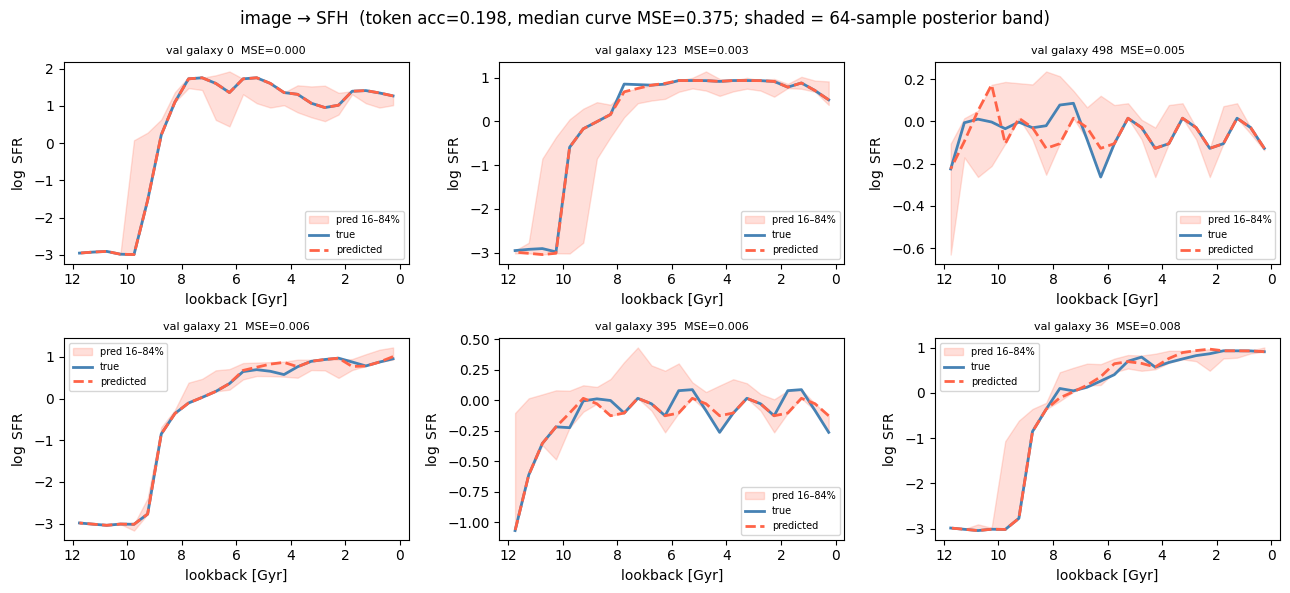

In [7]:
from sim.inference import run_inference, run_inference_scalar_ev, run_inference_samples

enc = ["tok_sim_galaxy_image"]
N_SAMPLES = 64                      # posterior draws used for the uncertainty bands

# point prediction (argmax) ...
pred_tok = run_inference(model, val_tokens, enc, ["tok_sim_sfh"],
                         batch_size=INFER_BATCH, device=DEVICE)["tok_sim_sfh"]
# ... and a posterior sample of whole token sequences for the uncertainty band
samp_tok = run_inference_samples(model, val_tokens, enc, ["tok_sim_sfh"],
                                 n_samples=N_SAMPLES, batch_size=INFER_BATCH,
                                 device=DEVICE)["tok_sim_sfh"]            # (S, N, 6)

sfh_codec = infer_codecs["tok_sim_sfh"]
S, N, T = samp_tok.shape
with torch.no_grad():
    true = sfh_codec.decode(val_tokens["tok_sim_sfh"].to(DEVICE)).value.cpu()
    pred = sfh_codec.decode(pred_tok.to(DEVICE)).value.cpu()
    band = sfh_codec.decode(samp_tok.reshape(S * N, T).to(DEVICE)).value[:, 1].cpu()
    band = band.reshape(S, N, -1)                       # (S, N, 24) sampled log-SFR curves
lo, hi = band.quantile(0.16, 0), band.quantile(0.84, 0)  # (N, 24)
tgrid = true[0, 0]
mse = ((true[:, 1] - pred[:, 1]) ** 2).mean(dim=1)
order = torch.argsort(mse)                # best-reconstructed first

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, g in zip(axes.flat, order[:6].tolist()):
    ax.fill_between(tgrid, lo[g], hi[g], color="tomato", alpha=0.2, label="pred 16–84%")
    ax.plot(tgrid, true[g, 1], color="steelblue", lw=2, label="true")
    ax.plot(tgrid, pred[g, 1], color="tomato", lw=2, ls="--", label="predicted")
    ax.invert_xaxis(); ax.set_xlabel("lookback [Gyr]"); ax.set_ylabel(r"$\log$ SFR")
    ax.set_title(f"val galaxy {g}  MSE={mse[g]:.3f}", fontsize=8)
    ax.legend(fontsize=7)
tok_acc = (pred_tok == val_tokens["tok_sim_sfh"]).float().mean().item()
fig.suptitle(f"image → SFH  (token acc={tok_acc:.3f}, median curve MSE={mse.median():.3f}; "
             f"shaded = {N_SAMPLES}-sample posterior band)")
fig.tight_layout(); plt.show()

### Demo B — image → gas & dark-matter density profiles

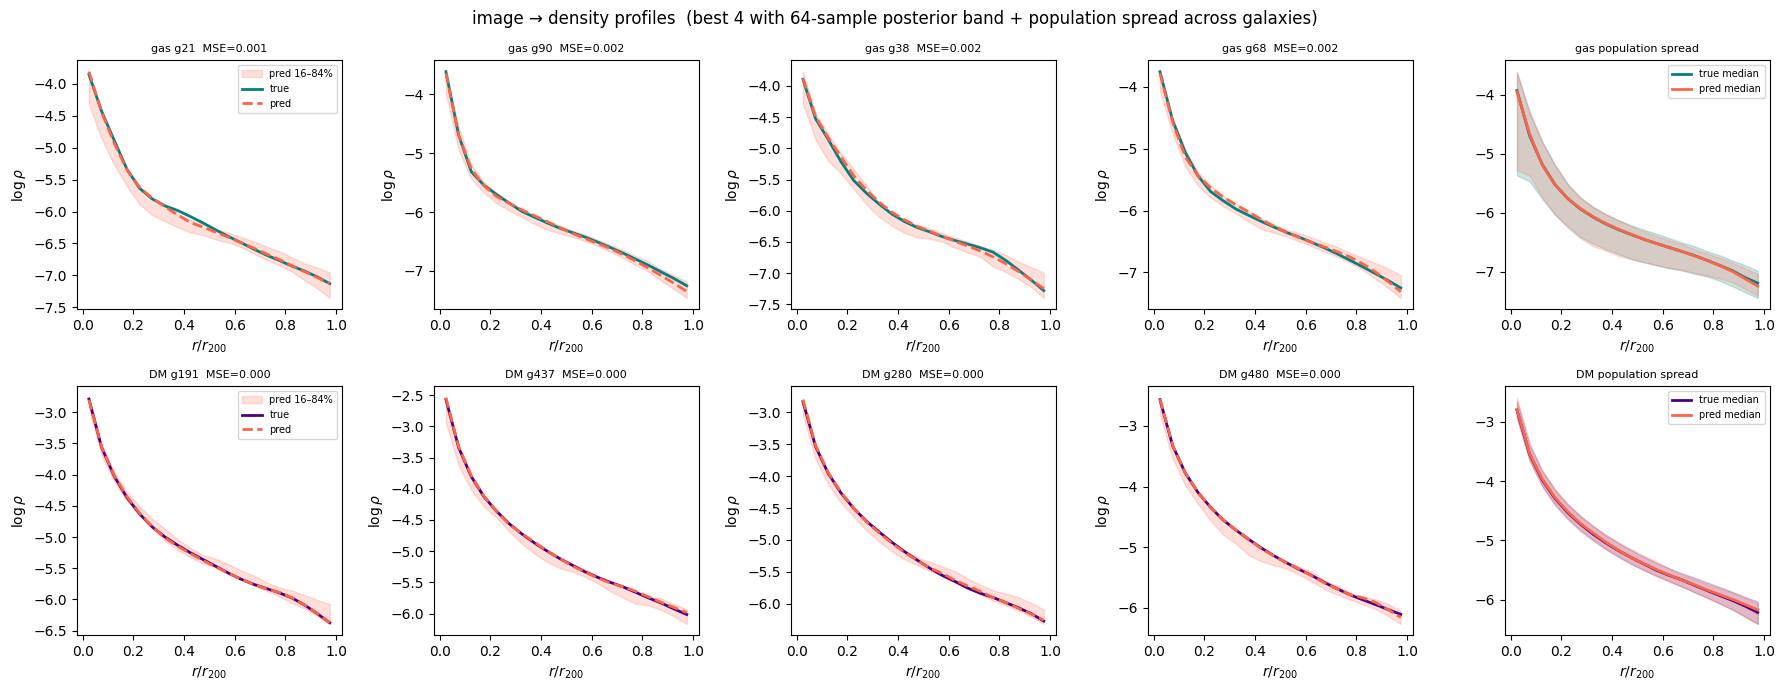

In [8]:
keys = ["tok_sim_gas_profile", "tok_sim_dm_profile"]
pred = run_inference(model, val_tokens, enc, keys, batch_size=INFER_BATCH, device=DEVICE)
samp = run_inference_samples(model, val_tokens, enc, keys, n_samples=N_SAMPLES,
                             batch_size=INFER_BATCH, device=DEVICE)        # {key: (S,N,5)}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, (key, lab, color) in enumerate([
        ("tok_sim_gas_profile", "gas", "teal"),
        ("tok_sim_dm_profile",  "DM",  "indigo")]):
    codec = infer_codecs[key]
    S, N, T = samp[key].shape
    with torch.no_grad():
        t = codec.decode(val_tokens[key].to(DEVICE)).value.cpu()
        p = codec.decode(pred[key].to(DEVICE)).value.cpu()
        b = codec.decode(samp[key].reshape(S * N, T).to(DEVICE)).value[:, 1].cpu()
        b = b.reshape(S, N, -1)                          # (S, N, 20) sampled log-rho curves
    rgrid = t[0, 0]
    blo, bhi = b.quantile(0.16, 0), b.quantile(0.84, 0)  # (N, 20) per-galaxy band
    mse = ((t[:, 1] - p[:, 1]) ** 2).mean(dim=1)
    order = torch.argsort(mse)
    for j in range(4):
        g = int(order[j]); ax = axes[row][j]
        ax.fill_between(rgrid, blo[g], bhi[g], color="tomato", alpha=0.2, label="pred 16–84%")
        ax.plot(rgrid, t[g, 1], color=color, lw=2, label="true")
        ax.plot(rgrid, p[g, 1], color="tomato", lw=2, ls="--", label="pred")
        ax.set_xlabel(r"$r/r_{200}$"); ax.set_ylabel(r"$\log\rho$")
        ax.set_title(f"{lab} g{g}  MSE={mse[g]:.3f}", fontsize=8)
        if j == 0: ax.legend(fontsize=7)
    # population ensemble: spread ACROSS galaxies (true vs predicted), a different cut
    ax = axes[row][4]
    for arr, c2, l2 in [(t[:, 1], color, "true"), (p[:, 1], "tomato", "pred")]:
        med = arr.median(0).values
        plo = arr.quantile(0.16, 0); phi = arr.quantile(0.84, 0)
        ax.fill_between(rgrid, plo, phi, color=c2, alpha=0.2)
        ax.plot(rgrid, med, color=c2, lw=2, label=f"{l2} median")
    ax.set_title(f"{lab} population spread", fontsize=8); ax.set_xlabel(r"$r/r_{200}$")
    ax.legend(fontsize=7)
fig.suptitle(f"image → density profiles  (best 4 with {N_SAMPLES}-sample posterior band "
             f"+ population spread across galaxies)")
fig.tight_layout(); plt.show()

### Demo C — image → scalars (halo mass, stellar mass, size, SFR)

For a single-token ordinal scalar the softmax over the codebook is a 1-D posterior, and
there are **two ways to turn it into a point estimate** — they behave very differently, so
it is worth being explicit:

* **argmax (modal bin).** The most-likely bin, decoded to its value. It **preserves the
  dynamic range** — the true-vs-pred scatter sits on the 1:1 line (slope ≈ 1, ~0 bias). This
  is the calibrated point prediction and the one to read for regression skill (it is what
  a calibrated regression model plots).
* **expected value** `E[x] = Σ p(bin)·value(bin)`. A smoother estimate, but with 1024 fine
  ordinal bins even a little probability leaking onto far bins drags the mean toward the
  centre of the distribution — so when the image only loosely constrains the target the EV
  **regresses to the mean** (slope < 1, a *compressed* scatter that looks "biased"). This is
  a fundamental property of the posterior mean, not a model defect: M_halo (which a face-on
  image constrains least directly) has the broadest posterior and therefore the strongest
  shrinkage. **Use the EV only for the correlation `r` and for its posterior width as a 1σ
  uncertainty — not for slope-to-truth.**

Below we plot the **argmax** point estimate (firebrick best-fit ≈ 1:1) and overlay the EV
best-fit (dotted green) so the mean-regression is visible. The error bars are the EV
posterior σ (a 1σ uncertainty in physical units); the **1σ coverage** (fraction of galaxies
whose true value lands within ±σ of the prediction) checks whether the error bars are
honest — a calibrated posterior sits near the ideal **0.68**.

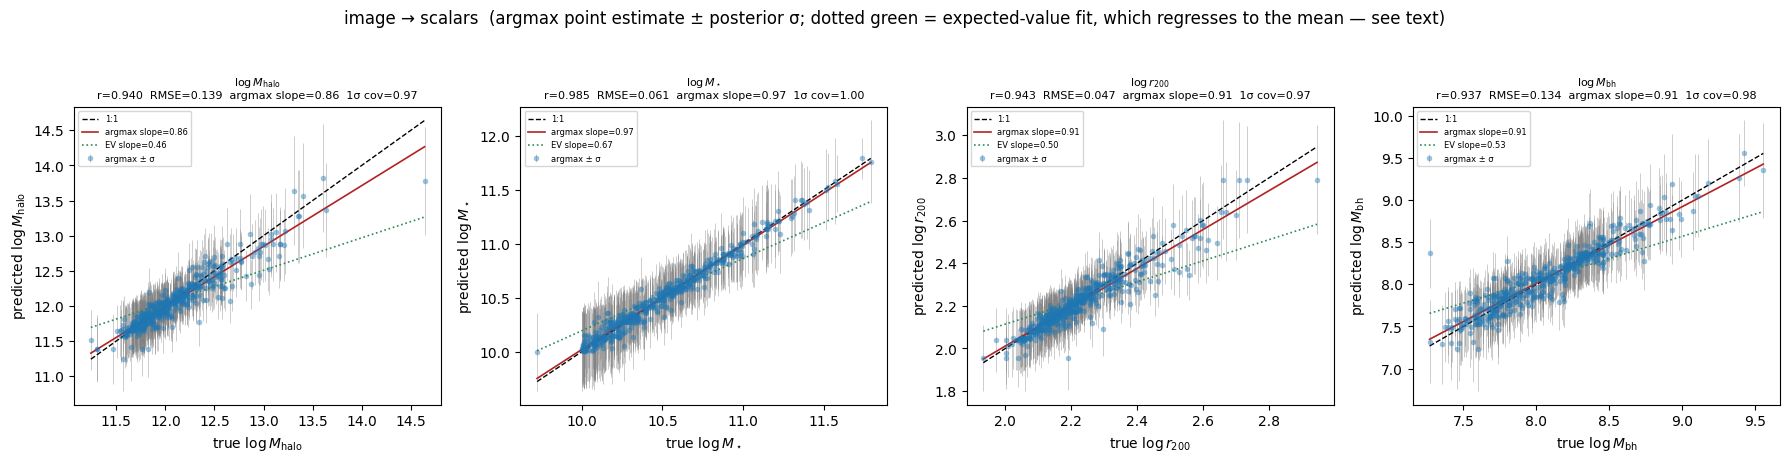

In [9]:
from sim.inference import run_inference, run_inference_scalar_ev

scalar_targets = [("tok_sim_mhalo", r"$\log M_{\rm halo}$"),
                  ("tok_sim_mstar", r"$\log M_\star$"),
                  ("tok_sim_r200",  r"$\log r_{200}$"),
                  ("tok_sim_mbh",   r"$\log M_{\rm bh}$")]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
for ax, (key, lab) in zip(axes, scalar_targets):
    codec = infer_codecs[key]
    V = codec.quantizer.codebook_size
    with torch.no_grad():
        true = codec.quantizer.decode(val_tokens[key].squeeze(-1).to(DEVICE)).cpu().numpy()
    # (1) argmax point estimate (capped to the codebook) — preserves dynamic range
    amax = run_inference(model, val_tokens, enc, [key], batch_size=INFER_BATCH,
                         device=DEVICE, decoder_vocab_caps={key: V})[key]
    pred_a = codec.quantizer.decode(amax.squeeze(-1).to(DEVICE)).cpu().numpy()
    # (2) expected value + posterior sigma (1σ); the EV regresses toward the mean
    pred_ev, std = run_inference_scalar_ev(model, val_tokens, codec, key, enc,
                                           batch_size=INFER_BATCH, device=DEVICE,
                                           return_std=True)
    r       = float(np.corrcoef(true, pred_a)[0, 1])
    sa, ia  = np.polyfit(true, pred_a, 1)            # argmax slope/intercept
    se, ie  = np.polyfit(true, pred_ev, 1)           # EV slope/intercept (shrunk)
    rmse_a  = float(np.sqrt(np.mean((pred_a - true) ** 2)))
    cover   = float(np.mean(np.abs(true - pred_a) <= std))   # ideal ≈ 0.68

    ax.errorbar(true, pred_a, yerr=std, fmt="o", ms=4, alpha=0.45, ecolor="gray",
                elinewidth=0.6, capsize=0, mfc="C0", mec="none", label="argmax ± σ")
    lo, hi = float(true.min()), float(true.max()); ref = np.linspace(lo, hi, 100)
    ax.plot(ref, ref, "k--", lw=1, label="1:1")
    ax.plot(ref, sa * ref + ia, color="firebrick", lw=1.2, label=f"argmax slope={sa:.2f}")
    ax.plot(ref, se * ref + ie, color="seagreen", lw=1.2, ls=":", label=f"EV slope={se:.2f}")
    ax.set_xlabel(f"true {lab}"); ax.set_ylabel(f"predicted {lab}")
    ax.set_title(f"{lab}\nr={r:.3f}  RMSE={rmse_a:.3f}  argmax slope={sa:.2f}  "
                 f"1σ cov={cover:.2f}", fontsize=8)
    ax.legend(fontsize=6, loc="best")
fig.suptitle("image → scalars  (argmax point estimate ± posterior σ; dotted green = "
             "expected-value fit, which regresses to the mean — see text)", y=1.04)
fig.tight_layout(); plt.show()

## Summary

One masked multimodal transformer, trained on the Tutorial-1 tokens, now predicts
**any** galaxy modality from **any** other — *with* a per-prediction uncertainty.
Above we conditioned on the face-on image alone and recovered the star-formation
history, the gas/DM density profiles, and the scalar masses/size/SFR — each a
different `p(target | image)` learned by the *same* weights, and each reported with
its posterior spread.

**The recipe.** Galaxy image **pinned to the encoder**; **stochastic mask
fraction** `MASK_FRAC = (0.15, 0.85)`; **soft cross-entropy** (σ = 1 bin) on the
ordinal scalars so their posteriors are calibrated; **deterministic validation**
(`val_seed`) so checkpoint selection is reliable. Trained for `EPOCHS = 120`
(cosine LR), FourM-tiny (52.9 M params), best validation loss 1.71.

**The payoff — image → scalar regression** (held-out 500-galaxy validation set,
**argmax** point estimate, which preserves the dynamic range; `r` is the Pearson
correlation):

| target | Pearson *r* | RMSE | slope |
|--------|------------:|-----:|------:|
| → M⋆        | **0.985** | 0.061 dex | 0.97 |
| → M_halo    | **0.940** | 0.139 dex | 0.87 |
| → r200      | **0.943** | 0.047     | 0.91 |
| → M_bh      | **0.937** | 0.134 dex | 0.91 |

A single face-on image pins down stellar mass to **0.06 dex** and the other
scalars to within ~0.13 dex — the transformer has learned the tight physical
correlations between a galaxy's appearance and its mass, size, and central black
hole.

**argmax vs. expected value.** For an ordinal scalar the codebook softmax is a 1-D
posterior, and the two point estimates behave differently: the **argmax** preserves
the dynamic range (slope ≈ 1), while the **expected value** regresses toward the
mean (slope < 1) because probability leaking onto far ordinal bins pulls `E[x]`
toward the centre — strongest for M_halo, which a face-on image constrains least
directly. Use the argmax for the value, and the EV's width as a 1σ uncertainty.

**Uncertainties two ways.**
* *Sequences* (SFH, profiles): sample whole token sequences from the per-token
  posterior, decode each, and take per-point 16–84% bands (`run_inference_samples`).
* *Scalars*: the codebook softmax is a 1-D posterior → report the argmax value ± its
  σ, and check the 1σ coverage against the ideal 0.68
  (`run_inference_scalar_ev(return_std=True)`).

**What to try next**
* Change `enc` (e.g. add `"tok_sim_sfh"`) to condition on more modalities and watch
  the bands tighten.
* Predict in the other direction (scalars → image is a generation task; FourM
  supports iterative decoding for the 1024-token image — see
  `aion/fourm/generate.py`).
* Scale up: a bigger `MODEL`, more `EPOCHS`, or more training galaxies.

**To (re)train:** `python -m sim.train_transformer` (after tokenizing with the
Tutorial-1 codecs). The published checkpoint was trained in ~11 h on one V100.